In [1]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from datetime import datetime

In [2]:
# force 'normal' text style for math text
mpl.rcParams['mathtext.default'] = 'regular'

# set global seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [3]:
ts = pd.read_csv('MOD-00677.csv')
COLS_TO_INCLUDE = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','pm25','co','o3','no','no2','rh','temp']
ts = ts[COLS_TO_INCLUDE]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-29T21:01:54Z,1.406,0.240,0.072,0.025,0.011,0.018,1.900,683.923,30.471,1.886,33.070,38.3,1.9
1,2025-12-29T21:00:54Z,1.506,0.250,0.084,0.007,0.015,0.011,1.662,686.849,31.187,1.822,33.099,37.8,2.0
2,2025-12-29T20:59:54Z,1.327,0.223,0.097,0.007,0.015,0.018,1.708,680.225,31.564,1.951,32.646,37.3,2.0
3,2025-12-29T20:58:54Z,1.364,0.234,0.080,0.010,0.017,0.011,1.776,680.170,31.616,1.953,32.904,36.8,2.0
4,2025-12-29T20:57:54Z,1.279,0.255,0.103,0.027,0.014,0.010,1.594,677.241,31.343,1.823,31.740,36.3,2.0


In [4]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local'],format="%Y-%m-%dT%H:%M:%SZ") #convert timestamp column to pandas timestamp format
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-29 21:01:54,1.406,0.240,0.072,0.025,0.011,0.018,1.900,683.923,30.471,1.886,33.070,38.3,1.9
1,2025-12-29 21:00:54,1.506,0.250,0.084,0.007,0.015,0.011,1.662,686.849,31.187,1.822,33.099,37.8,2.0
2,2025-12-29 20:59:54,1.327,0.223,0.097,0.007,0.015,0.018,1.708,680.225,31.564,1.951,32.646,37.3,2.0
3,2025-12-29 20:58:54,1.364,0.234,0.080,0.010,0.017,0.011,1.776,680.170,31.616,1.953,32.904,36.8,2.0
4,2025-12-29 20:57:54,1.279,0.255,0.103,0.027,0.014,0.010,1.594,677.241,31.343,1.823,31.740,36.3,2.0


## Full Timeseries Plot

In [5]:
#taking daily average of ts. round to floor of the day
ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-08-17,26.953150,3.336863,0.607413,0.109887,0.112263,0.083425,11.681912,1000.413450,31.645312,1.560050,18.696487,80.276250,26.205000
2025-08-18,4.493020,0.506997,0.160147,0.044462,0.056553,0.045044,4.397014,702.859535,34.594286,2.496981,22.155143,58.906319,23.929792
2025-08-19,1.399856,0.323547,0.175208,0.063433,0.087845,0.076017,2.409976,691.646587,39.694824,2.288694,20.205176,47.952153,24.290000
2025-08-20,2.930661,0.609337,0.300367,0.103306,0.139531,0.120591,3.960870,735.205785,31.583126,2.004015,22.240042,76.998819,20.140903
2025-08-21,2.246961,0.381428,0.147719,0.042288,0.052774,0.044838,3.006703,714.660585,34.583653,2.447330,21.869869,73.259306,19.337083


In [6]:
ts_day['pm25_c'] = 3.491 + 0.576*ts_day['pm25'] - 0.047*ts_day['rh'] + 0.070*ts_day['temp']
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-08-17,26.953150,3.336863,0.607413,0.109887,0.112263,0.083425,11.681912,1000.413450,31.645312,1.560050,18.696487,80.276250,26.205000,8.281148
2025-08-18,4.493020,0.506997,0.160147,0.044462,0.056553,0.045044,4.397014,702.859535,34.594286,2.496981,22.155143,58.906319,23.929792,4.930168
2025-08-19,1.399856,0.323547,0.175208,0.063433,0.087845,0.076017,2.409976,691.646587,39.694824,2.288694,20.205176,47.952153,24.290000,4.325695
2025-08-20,2.930661,0.609337,0.300367,0.103306,0.139531,0.120591,3.960870,735.205785,31.583126,2.004015,22.240042,76.998819,20.140903,3.563380
2025-08-21,2.246961,0.381428,0.147719,0.042288,0.052774,0.044838,3.006703,714.660585,34.583653,2.447330,21.869869,73.259306,19.337083,3.133270


<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1313/2109157559.py:45: SyntaxWarning: invalid escape sequence '\m'
  ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)


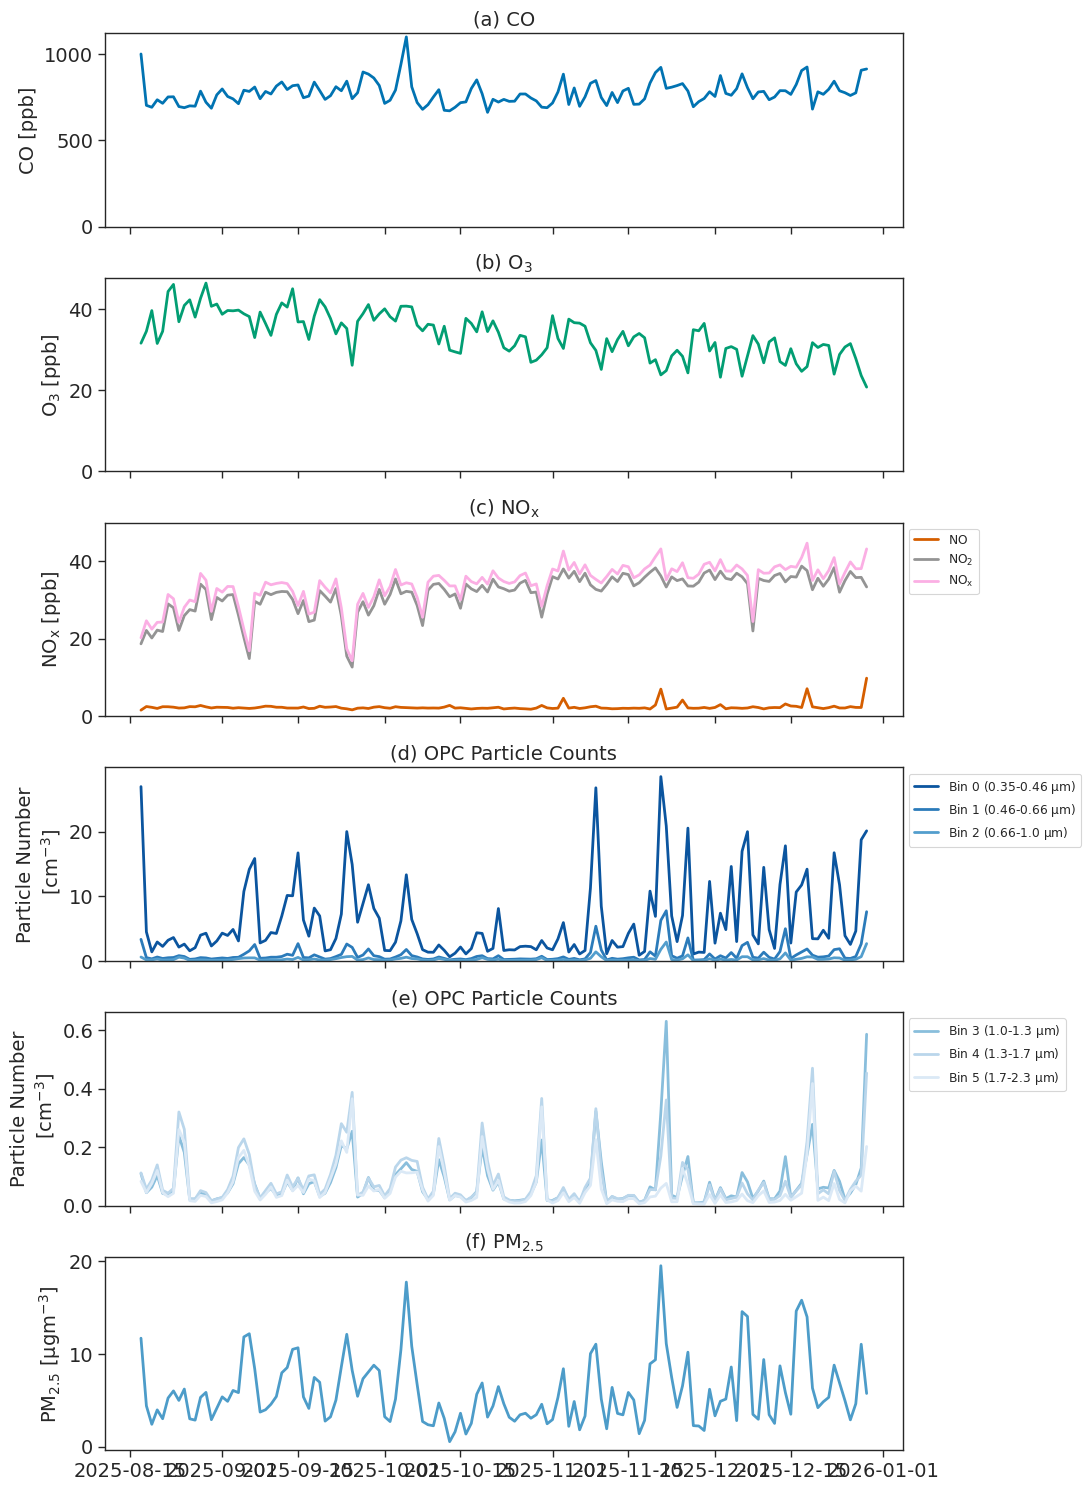

In [8]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(ts_day['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(0, None)

# plot the o3 on the second axis
ax[1].plot(ts_day['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(0, None)

#plot nox on the 2nd axis
ax[2].plot(ts_day['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(ts_day['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(ts_day['no2']+ts_day['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 50)


# plot the OPC bins on the 5th and 6th rows
ax[3].plot(ts_day['bin0'], lw=2, label=r'Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(ts_day['bin1'], lw=2, label=r'Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(ts_day['bin2'], lw=2, label=r'Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(ts_day['bin3'], lw=2, label=r'Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(ts_day['bin4'], lw=2, label=r'Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(ts_day['bin5'], lw=2, label=r'Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(ts_day['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(d) OPC Particle Counts", fontsize=14)
ax[4].set_title("(e) OPC Particle Counts", fontsize=14)
ax[5].set_title("(f) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

# force a tight layout
plt.tight_layout()

fig.savefig('timeseries_MOD-00677.png')

## Dirunal Plots

In [9]:
#taking daily average of ts. round to floor of the day
ts_hour = ts.groupby(ts['timestamp_local'].dt.floor('h')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_hour = ts_hour.set_index('timestamp_local')
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-08-17 22:00:00,22.960800,2.214350,0.407450,0.070800,0.070950,0.049200,11.061450,902.124450,34.287550,1.569600,11.111600,78.575000,26.300000
2025-08-17 23:00:00,28.283933,3.711033,0.674067,0.122917,0.126033,0.094833,11.888733,1033.176450,30.764567,1.556867,21.224783,80.843333,26.173333
2025-08-18 00:00:00,25.668817,2.903483,0.511950,0.082917,0.083483,0.062400,11.101167,876.038517,30.456150,1.494767,26.885883,80.356667,26.035000
2025-08-18 01:00:00,17.285350,1.578717,0.243817,0.039767,0.045017,0.038067,8.876700,688.901717,29.252250,1.842000,17.816700,73.015000,25.135000
2025-08-18 02:00:00,6.093467,0.526033,0.103133,0.021033,0.025583,0.025600,3.847200,630.014417,28.177800,1.778433,17.192250,69.060000,22.888333


In [10]:
ts_hour['pm25_c'] = 2.111 + 0.298*ts_hour['pm25'] + 0.024*ts_hour['rh'] + 0.050*ts_hour['temp']
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-08-17 22:00:00,22.960800,2.214350,0.407450,0.070800,0.070950,0.049200,11.061450,902.124450,34.287550,1.569600,11.111600,78.575000,26.300000,8.608112
2025-08-17 23:00:00,28.283933,3.711033,0.674067,0.122917,0.126033,0.094833,11.888733,1033.176450,30.764567,1.556867,21.224783,80.843333,26.173333,8.902749
2025-08-18 00:00:00,25.668817,2.903483,0.511950,0.082917,0.083483,0.062400,11.101167,876.038517,30.456150,1.494767,26.885883,80.356667,26.035000,8.649458
2025-08-18 01:00:00,17.285350,1.578717,0.243817,0.039767,0.045017,0.038067,8.876700,688.901717,29.252250,1.842000,17.816700,73.015000,25.135000,7.765367
2025-08-18 02:00:00,6.093467,0.526033,0.103133,0.021033,0.025583,0.025600,3.847200,630.014417,28.177800,1.778433,17.192250,69.060000,22.888333,6.059322


In [11]:
#prepping data
ts_hour['Hour'] = ts_hour.index.hour
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour
timestamp_local,,,,,,,,,,,,,,,
2025-08-17 22:00:00,22.960800,2.214350,0.407450,0.070800,0.070950,0.049200,11.061450,902.124450,34.287550,1.569600,11.111600,78.575000,26.300000,8.608112,22
2025-08-17 23:00:00,28.283933,3.711033,0.674067,0.122917,0.126033,0.094833,11.888733,1033.176450,30.764567,1.556867,21.224783,80.843333,26.173333,8.902749,23
2025-08-18 00:00:00,25.668817,2.903483,0.511950,0.082917,0.083483,0.062400,11.101167,876.038517,30.456150,1.494767,26.885883,80.356667,26.035000,8.649458,0
2025-08-18 01:00:00,17.285350,1.578717,0.243817,0.039767,0.045017,0.038067,8.876700,688.901717,29.252250,1.842000,17.816700,73.015000,25.135000,7.765367,1
2025-08-18 02:00:00,6.093467,0.526033,0.103133,0.021033,0.025583,0.025600,3.847200,630.014417,28.177800,1.778433,17.192250,69.060000,22.888333,6.059322,2


In [12]:
#groupping by hour and calculate the mean
diurnal_data = ts_hour.groupby('Hour').mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
Hour,,,,,,,,,,,,,,
00:00,6.523418,1.187549,0.398109,0.096593,0.098712,0.068807,5.850640,788.939177,32.209910,2.419404,32.793370,61.498860,12.873709,5.974149
01:00,6.540065,1.085053,0.343790,0.082072,0.086963,0.065235,5.734379,776.969041,31.511076,2.563002,33.154097,62.753520,12.539670,5.952913
02:00,6.525354,1.033361,0.328991,0.081160,0.088564,0.066738,5.589753,770.561398,30.952826,2.433326,33.019201,64.072268,12.205075,5.924735
03:00,6.684701,1.095345,0.357706,0.089254,0.095615,0.069679,5.530541,765.930771,30.362176,2.279795,33.041657,64.986319,11.939324,5.915739
04:00,6.764032,1.155635,0.354234,0.084900,0.091049,0.067157,5.397146,760.491273,29.780523,2.163030,33.039842,65.963156,11.684749,5.886703
05:00,6.977167,1.189810,0.366455,0.088091,0.094292,0.069333,5.482084,773.506769,28.853770,2.092074,33.726212,66.914646,11.467260,5.923976
06:00,7.173030,1.216304,0.376676,0.092304,0.098531,0.071448,5.625885,797.089971,27.626741,2.346441,34.242082,67.525421,11.274522,5.971850
07:00,7.170829,1.118565,0.370933,0.095537,0.104418,0.075912,5.934773,816.335752,27.749189,2.707370,33.044539,65.527854,11.865269,6.045494
08:00,6.681857,1.024941,0.360174,0.095199,0.103497,0.071740,6.293590,817.391321,29.363933,3.024459,30.282980,58.993122,13.894204,6.097035


<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1313/831441002.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipykernel_1313/831441002.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r

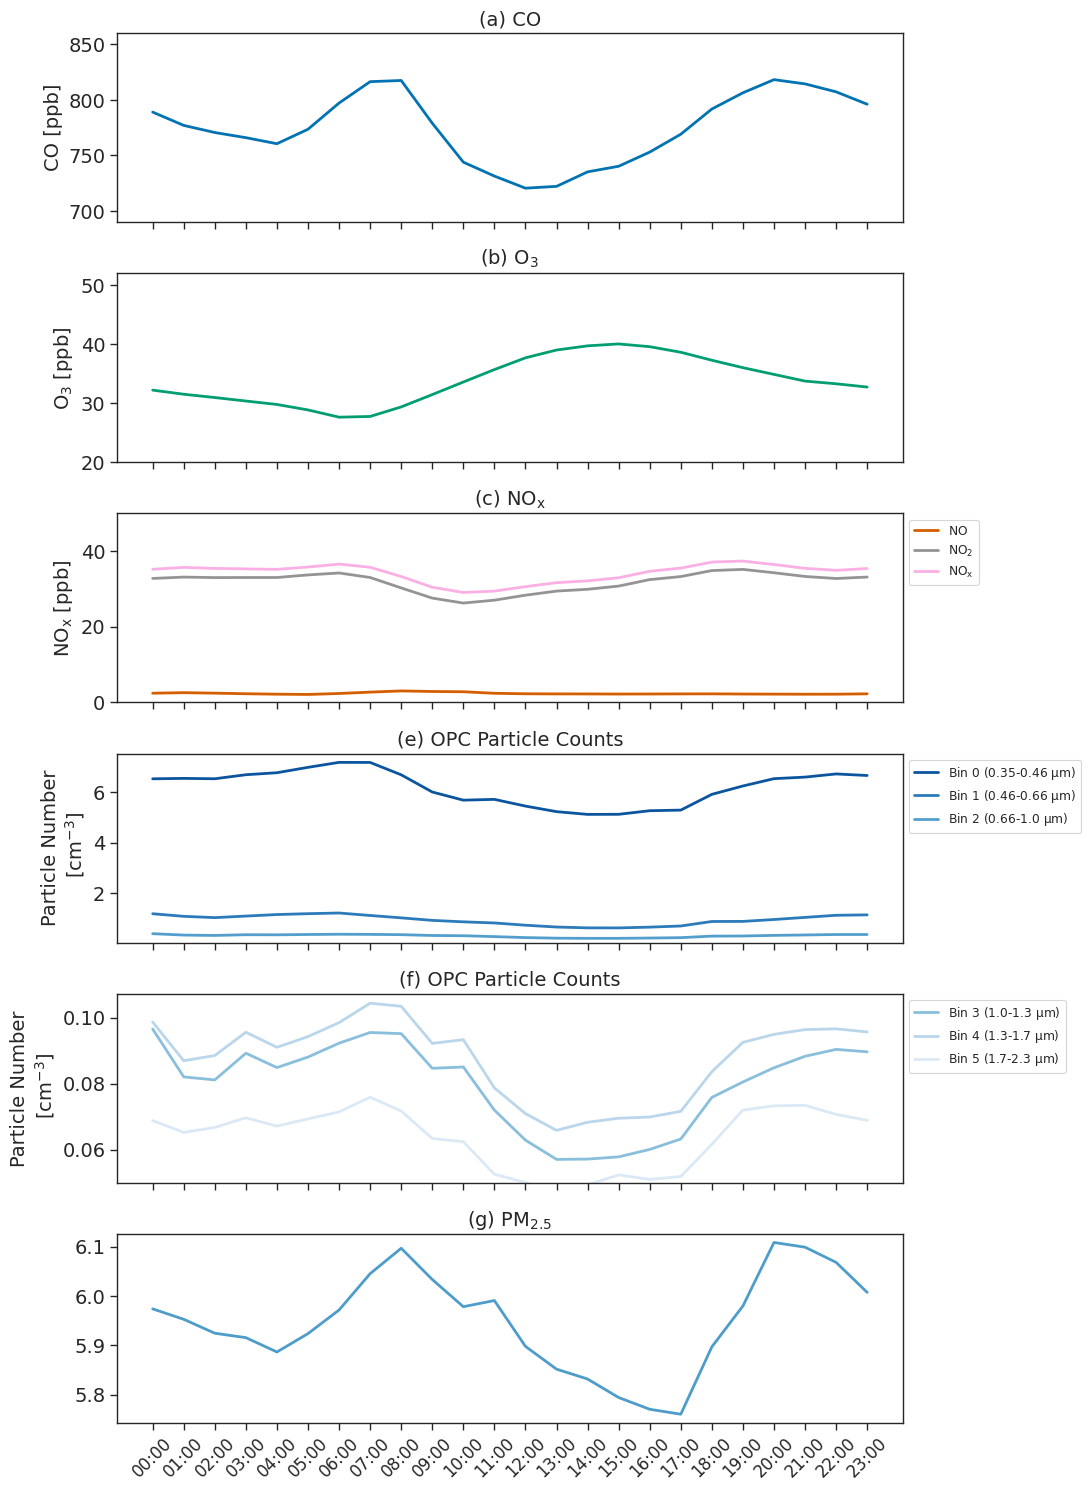

In [15]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(diurnal_data['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(690, 860)

# plot the o3 on the first axis
ax[1].plot(diurnal_data['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(20, 52)

#plot nox on the 2nd axis
ax[2].plot(diurnal_data['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(diurnal_data['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(diurnal_data['no2']+diurnal_data['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 50)

# plot the OPC bins on the 3rd and 4th rows
ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(diurnal_data['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0.05, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(diurnal_data['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(diurnal_data['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(diurnal_data['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0.05, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(diurnal_data['pm25_c'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(e) OPC Particle Counts", fontsize=14)
ax[4].set_title("(f) OPC Particle Counts", fontsize=14)
ax[5].set_title("(g) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# set x as hours
ax[5].set_xticks(range(24))
ax[5].set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

plt.xticks(range(0, 24), size = 12)
plt.xticks(rotation=45)

# force a tight layout
plt.tight_layout()

fig.savefig('dirunal_MOD-00677_allfeatures.png')

## Diurnal by Season

In [18]:
def month_to_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

In [16]:
ts_hour = ts_hour.reset_index()

In [19]:
#prepping data
ts_hour['Season'] = ts_hour['timestamp_local'].dt.month.apply(month_to_season)
ts_hour.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour,Season
0,2025-08-17 22:00:00,22.960800,2.214350,0.407450,0.070800,0.070950,0.049200,11.061450,902.124450,34.287550,1.569600,11.111600,78.575000,26.300000,8.608112,22,Summer
1,2025-08-17 23:00:00,28.283933,3.711033,0.674067,0.122917,0.126033,0.094833,11.888733,1033.176450,30.764567,1.556867,21.224783,80.843333,26.173333,8.902749,23,Summer
2,2025-08-18 00:00:00,25.668817,2.903483,0.511950,0.082917,0.083483,0.062400,11.101167,876.038517,30.456150,1.494767,26.885883,80.356667,26.035000,8.649458,0,Summer
3,2025-08-18 01:00:00,17.285350,1.578717,0.243817,0.039767,0.045017,0.038067,8.876700,688.901717,29.252250,1.842000,17.816700,73.015000,25.135000,7.765367,1,Summer
4,2025-08-18 02:00:00,6.093467,0.526033,0.103133,0.021033,0.025583,0.025600,3.847200,630.014417,28.177800,1.778433,17.192250,69.060000,22.888333,6.059322,2,Summer


In [20]:
grouped_by_season_hour = ts_hour.drop(columns='timestamp_local').groupby(['Season', 'Hour']).mean()
grouped_by_season_hour

bin0      bin1      bin2      bin3      bin4      bin5  \
Season Hour                                                                
Autumn 0      5.336491  1.029705  0.389094  0.100174  0.102146  0.069396   
       1      5.606210  0.903763  0.311588  0.079276  0.086827  0.065047   
       2      5.887851  0.890096  0.303009  0.080019  0.089865  0.068466   
       3      6.351028  1.034589  0.355356  0.092631  0.099566  0.071917   
       4      6.513263  1.090470  0.338999  0.083588  0.089549  0.065440   
...                ...       ...       ...       ...       ...       ...   
Winter 19     8.868087  1.121767  0.333121  0.068937  0.061257  0.040918   
       20     9.055294  1.176269  0.346985  0.071471  0.065619  0.042721   
       21     9.409198  1.326534  0.389213  0.082275  0.071947  0.045861   
       22    10.539971  1.737248  0.482070  0.101199  0.091383  0.053525   
       23    11.380344  2.022590  0.530659  0.103692  0.095189  0.060874   

                 pm25          co         o3        no        no2         rh  \
Season Hour                                                                    
Autumn 0     5.601046  792.716911  33.081529  2.432797  32.365388  61.662593   
       1     5.539984  783.115057  32.085538  2.654304  32.704822  63.352386   
       2     5.496271  775.154073  31.413949  2.485674  32.572637  64.840148   
       3     5.530869  768.376030  30.747707  2.281060  32.790693  66.087042   
       4     5.313760  758.633400  30.057122  2.103956  32.578265  67.139071   
...               ...         ...        ...       ...        ...        ...   
Winter 19    6.928240  792.287511  28.556290  2.144620  36.195837  55.830115   
       20    7.295040  799.658346  28.161828  2.214730  36.101327  56.318448   
       21    7.460750  803.312218  27.868361  2.266908  35.928887  57.153851   
       22    7.525624  799.558614  27.693702  2.262262  36.088026  59.641726   
       23    7.370843  797.585851  27.397228  2.347879  36.017968  61.122738   

                  temp    pm25_c  
Season Hour                       
Autumn 0     15.240481  6.022038  
       1     14.847012  6.024723  
       2     14.477278  6.028916  
       3     14.173964  6.053986  
       4     13.909666  6.001321  
...                ...       ...  
Winter 19     2.325000  5.631788  
       20     2.049253  5.739027  
       21     1.876379  5.799815  
       22     1.686071  5.869341  
       23     1.481369  5.848526  

[72 rows x 14 columns]

In [21]:
grouped_by_season_hour = grouped_by_season_hour.reset_index()
grouped_by_season_hour

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
0,Autumn,0,5.336491,1.029705,0.389094,0.100174,0.102146,0.069396,5.601046,792.716911,33.081529,2.432797,32.365388,61.662593,15.240481,6.022038
1,Autumn,1,5.606210,0.903763,0.311588,0.079276,0.086827,0.065047,5.539984,783.115057,32.085538,2.654304,32.704822,63.352386,14.847012,6.024723
2,Autumn,2,5.887851,0.890096,0.303009,0.080019,0.089865,0.068466,5.496271,775.154073,31.413949,2.485674,32.572637,64.840148,14.477278,6.028916
3,Autumn,3,6.351028,1.034589,0.355356,0.092631,0.099566,0.071917,5.530869,768.376030,30.747707,2.281060,32.790693,66.087042,14.173964,6.053986
4,Autumn,4,6.513263,1.090470,0.338999,0.083588,0.089549,0.065440,5.313760,758.633400,30.057122,2.103956,32.578265,67.139071,13.909666,6.001321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,Winter,19,8.868087,1.121767,0.333121,0.068937,0.061257,0.040918,6.928240,792.287511,28.556290,2.144620,36.195837,55.830115,2.325000,5.631788
68,Winter,20,9.055294,1.176269,0.346985,0.071471,0.065619,0.042721,7.295040,799.658346,28.161828,2.214730,36.101327,56.318448,2.049253,5.739027
69,Winter,21,9.409198,1.326534,0.389213,0.082275,0.071947,0.045861,7.460750,803.312218,27.868361,2.266908,35.928887,57.153851,1.876379,5.799815
70,Winter,22,10.539971,1.737248,0.482070,0.101199,0.091383,0.053525,7.525624,799.558614,27.693702,2.262262,36.088026,59.641726,1.686071,5.869341


In [22]:
autumn_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Autumn']
winter_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Winter']
spring_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Spring']
summer_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Summer']

autumn_diurnal.index = autumn_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
winter_diurnal.index = winter_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
spring_diurnal.index = spring_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
summer_diurnal.index = summer_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))

In [23]:
autumn_diurnal

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
00:00,Autumn,0,5.336491,1.029705,0.389094,0.100174,0.102146,0.069396,5.601046,792.716911,33.081529,2.432797,32.365388,61.662593,15.240481,6.022038
01:00,Autumn,1,5.606210,0.903763,0.311588,0.079276,0.086827,0.065047,5.539984,783.115057,32.085538,2.654304,32.704822,63.352386,14.847012,6.024723
02:00,Autumn,2,5.887851,0.890096,0.303009,0.080019,0.089865,0.068466,5.496271,775.154073,31.413949,2.485674,32.572637,64.840148,14.477278,6.028916
03:00,Autumn,3,6.351028,1.034589,0.355356,0.092631,0.099566,0.071917,5.530869,768.376030,30.747707,2.281060,32.790693,66.087042,14.173964,6.053986
04:00,Autumn,4,6.513263,1.090470,0.338999,0.083588,0.089549,0.065440,5.313760,758.633400,30.057122,2.103956,32.578265,67.139071,13.909666,6.001321
05:00,Autumn,5,6.800474,1.101858,0.341969,0.084402,0.089288,0.064616,5.344677,771.439343,29.164035,1.985722,33.387391,68.011592,13.710543,6.021519
06:00,Autumn,6,7.410386,1.233247,0.371284,0.090232,0.093245,0.065920,5.611264,798.586877,27.582518,2.157888,34.340138,68.974011,13.435349,6.110300
07:00,Autumn,7,7.429842,1.104889,0.348341,0.088580,0.095599,0.068747,5.946587,818.026215,27.734198,2.256736,33.277936,67.104715,13.982759,6.192734
08:00,Autumn,8,6.695194,0.958216,0.326161,0.087628,0.098157,0.070252,6.335832,819.937577,29.396705,2.440919,29.616790,59.995788,16.115824,6.244768
09:00,Autumn,9,5.771777,0.804050,0.279212,0.076687,0.088278,0.063575,6.176557,774.677290,31.473695,2.462579,26.868726,52.646503,18.580658,6.144163


In [24]:
seasons_order = [winter_diurnal, spring_diurnal, summer_diurnal, autumn_diurnal]

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1313/2061922979.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipykernel_1313/2061922979.py:41: SyntaxWarning: invalid escape sequence '\m

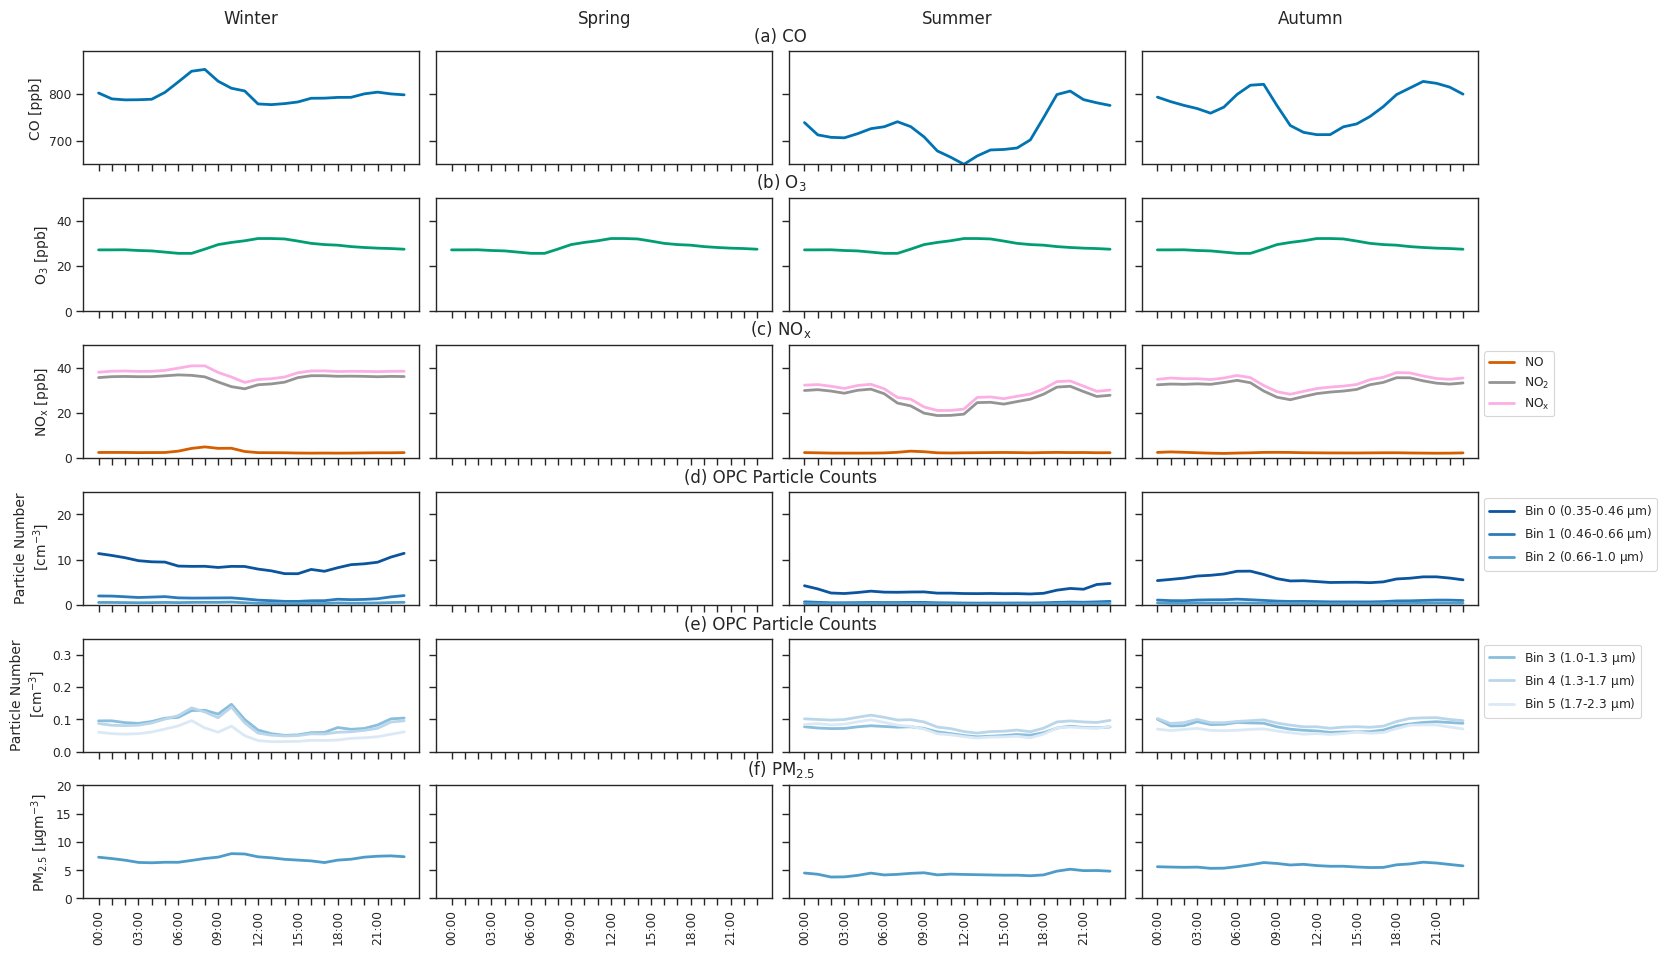

In [26]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=4, figsize=(18,11), sharex=True)
plt.subplots_adjust(hspace = 0.3, wspace = 0.05)

# grab the current color palette
cmap = sns.color_palette()

#iterate through seasons
for i in range(len(seasons_order)):

    #set ax column labels as season
    ax[0,0].set_title("Winter", fontsize=12, pad = 20)
    ax[0,1].set_title("Spring", fontsize=12, pad = 20)
    ax[0,2].set_title("Summer", fontsize=12, pad = 20)
    ax[0,3].set_title("Autumn", fontsize=12, pad = 20)

    # plot the CO data and label the axis
    ax[0,0].set_ylabel("CO [ppb]", fontsize=10)
    ax[0,i].plot(seasons_order[i]['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
    ax[0,i].set_ylim(650, 890)
    ax[0,i].set_xticks(range(0, 2))
    ax[0,i].set_xticks(seasons_order[i].index)

    # plot the o3 on the second axis
    ax[1,0].set_ylabel("$O_3$ [ppb]", fontsize=10)
    ax[1,i].plot(winter_diurnal['o3'], lw=2, label="$O_3$", color=cmap[2])
    ax[1,i].set_ylim(0, 50)

    #plot nox on the 3rd axis
    ax[2,0].set_ylabel("$NO_x$ [ppb]", fontsize=10)
    ax[2,i].plot(seasons_order[i]['no'], lw=2, label="$NO$", color=cmap[3])
    ax[2,i].plot(seasons_order[i]['no2'], lw=2, label="$NO_2$", color=cmap[7])
    ax[2,i].plot(seasons_order[i]['no2']+seasons_order[i]['no'], lw=2, label="$NO_x$", color=cmap[6])
    ax[2,i].set_ylim(0, 50)
    ax[2,3].legend(fontsize = 14)
    sns.move_legend(ax[2,3], "upper left", bbox_to_anchor=(1, 1))

    # plot the OPC bins on the 4th and 5th rows
    ax[3,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
    ax[3,i].plot(seasons_order[i]['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
    ax[3,i].plot(seasons_order[i]['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
    ax[3,i].set(ylim=(0, 25))
    ax[3,3].legend(fontsize = 14)
    sns.move_legend(ax[3,3], "upper left", bbox_to_anchor=(1, 1))

    ax[4,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[4,i].plot(seasons_order[i]['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
    ax[4,i].plot(seasons_order[i]['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
    ax[4,i].plot(seasons_order[i]['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
    ax[4,i].set(ylim=(0, 0.35))
    ax[4,3].legend(fontsize = 14)
    sns.move_legend(ax[4,3], "upper left", bbox_to_anchor=(1, 1))

    #plot pm25 on the 6th row
    ax[5,0].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=10)
    ax[5,i].plot(seasons_order[i]['pm25'], lw=2, label='$PM_{2.5}$ as reported',
             color=sns.color_palette()[0], alpha=0.7)
    ax[5,i].set(ylim=(0, 20))
    ax[5,i].set_xticks(range(24))
    ax[5,i].set_xticklabels(
    ['00:00','','','03:00','','','06:00','','','09:00','','','12:00','','','15:00','','','18:00','','','21:00','',''],
    rotation=90
)

    #remove subplot y ticks for subplots beyond winter
    if i>0:
        for j in range(6):
            ax[j,i].set_yticklabels([])

    # set titles for each panel
    row_titles = [
    "(a) CO",
    "(b) $O_3$",
    "(c) $NO_x$",
    "(d) OPC Particle Counts",
    "(e) OPC Particle Counts",
    "(f) $PM_{2.5}$"
]

for r, title in enumerate(row_titles):

    # left and right subplot positions
    left = ax[r,0].get_position()
    right = ax[r,-1].get_position()

    # horizontal center between first and last column
    x_center = (left.x0 + right.x1) / 2

    # slightly above the row
    y_top = left.y1 + 0.005

    fig.text(
        x_center,
        y_top,
        title,
        ha='center',
        va='bottom',
        fontsize=12
    )

fig.savefig('diurnal_by_season_MOD-00677.png')